# Cross-Validation: Eigen Squad Submissions — Batch Scoring

Automatically loads **all** `submissions/eigen_squad/*.csv` files within a configurable
date range and compares them against ENTSO-E actuals.

**Configure in Cell 2:**
- `START_DATE` — first day to include (inclusive)
- `END_DATE`   — last day to include (inclusive)

Re-run Cell 2 → Cell 9 whenever you want to score a new date window.

In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import sys
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import load_dotenv

# Resolve repo root (works from notebooks/ or repo root)
REPO_ROOT = Path(globals().get('__vsc_ipynb_file__', __file__) if '__file__' in dir() else '.').resolve()
for _p in [REPO_ROOT, REPO_ROOT.parent, REPO_ROOT.parent.parent]:
    _src = _p / 'src'
    if _src.exists() and str(_src) not in sys.path:
        sys.path.insert(0, str(_src))
        REPO_ROOT = _p
        break

load_dotenv(REPO_ROOT / '.env')

from energy_forecast.data.fetch import load_or_refresh_cache, load_load_data

print(f'Repo root : {REPO_ROOT}')
print('Imports OK')

Repo root : /Users/chilu/Own Projects/Forecasting-Energy-Consumption-Base-Model/notebooks
Imports OK


In [2]:
# ── Cell 2: Date range configuration ─────────────────────────────────────────
#
# Set START_DATE and END_DATE to the window you want to score.
# All matching files in submissions/eigen_squad/ will be picked up automatically.
# ─────────────────────────────────────────────────────────────────────────────
START_DATE = '2026-07-01'
END_DATE   = '2026-07-20'
# ─────────────────────────────────────────────────────────────────────────────

# Locate the true project root by searching for pyproject.toml / .git
def _find_project_root() -> Path:
    candidates = [
        REPO_ROOT,
        REPO_ROOT.parent,
        REPO_ROOT.parent.parent,
        Path('.').resolve(),
        Path('.').resolve().parent,
        Path('.').resolve().parent.parent,
    ]
    for base in dict.fromkeys(candidates):
        if (base / 'pyproject.toml').exists() or (base / '.git').is_dir():
            return base
    raise FileNotFoundError('Cannot locate project root (no pyproject.toml or .git found).')

PROJECT_ROOT    = _find_project_root()
SUBMISSIONS_DIR = PROJECT_ROOT / 'submissions' / 'eigen_squad'

start = pd.Timestamp(START_DATE, tz='UTC')
end   = pd.Timestamp(END_DATE,   tz='UTC')

print(f'Project root   : {PROJECT_ROOT}')
print(f'Scoring window : {start.date()} → {end.date()}  ({(end - start).days + 1} calendar days)')
print(f'Submissions dir: {SUBMISSIONS_DIR}')
assert SUBMISSIONS_DIR.is_dir(), f'Directory not found: {SUBMISSIONS_DIR}'

Project root   : /Users/chilu/Own Projects/Forecasting-Energy-Consumption-Base-Model
Scoring window : 2026-07-01 → 2026-07-20  (20 calendar days)
Submissions dir: /Users/chilu/Own Projects/Forecasting-Energy-Consumption-Base-Model/submissions/eigen_squad


In [3]:
# ── Cell 3: Discover & load submission CSVs ───────────────────────────────────

def _detect_columns(df: pd.DataFrame) -> tuple[str, str]:
    ts_candidates = ['timestamp_utc', 'timestamp', 'datetime', 'date', 'time', 'ds']
    fc_candidates = ['forecast_mw', 'load_mw', 'prediction', 'forecast', 'yhat', 'value', 'mw']
    cols_lower = {c.lower(): c for c in df.columns}
    ts_col = next((cols_lower[k] for k in ts_candidates if k in cols_lower), None)
    fc_col = next((cols_lower[k] for k in fc_candidates if k in cols_lower), None)
    if ts_col is None:
        ts_col = df.columns[0]
    if fc_col is None:
        numeric_cols = df.select_dtypes(include='number').columns
        if len(numeric_cols) == 0:
            raise ValueError('No numeric column found for forecast values.')
        fc_col = numeric_cols[0]
    return ts_col, fc_col


# Build expected date list and map to CSV paths
all_dates  = pd.date_range(start=start, end=end, freq='D', tz='UTC')
found_files   = {}
missing_dates = []

for d in all_dates:
    csv_path = SUBMISSIONS_DIR / f'{d.date()}.csv'
    if csv_path.exists():
        found_files[d.date()] = csv_path
    else:
        missing_dates.append(d.date())

print(f'Expected  : {len(all_dates)} days')
print(f'Found     : {len(found_files)} CSV files')
if missing_dates:
    print(f'Missing   : {len(missing_dates)} day(s) — {missing_dates}')
else:
    print('Missing   : none — full coverage!')

if not found_files:
    raise FileNotFoundError(
        f'No submission CSVs found in {SUBMISSIONS_DIR} for {START_DATE} → {END_DATE}.'
    )

# Load and concatenate all found files
frames = []
for date, path in sorted(found_files.items()):
    raw = pd.read_csv(path)
    ts_col, fc_col = _detect_columns(raw)
    df_day = raw[[ts_col, fc_col]].copy()
    df_day[ts_col] = pd.to_datetime(df_day[ts_col], utc=True)
    df_day = df_day.rename(columns={ts_col: 'timestamp_utc', fc_col: 'forecast_mw'})
    df_day['forecast_mw'] = pd.to_numeric(df_day['forecast_mw'], errors='coerce')
    frames.append(df_day)

df_pred = (
    pd.concat(frames, ignore_index=True)
    .set_index('timestamp_utc')
    .sort_index()
)

print(f'\nLoaded {len(df_pred):,} hourly rows  ({df_pred.index.min().date()} → {df_pred.index.max().date()})')
df_pred.head()

Expected  : 20 days
Found     : 17 CSV files
Missing   : 3 day(s) — [datetime.date(2026, 7, 1), datetime.date(2026, 7, 2), datetime.date(2026, 7, 10)]

Loaded 408 hourly rows  (2026-07-03 → 2026-07-20)


,forecast_mw
timestamp_utc,
2026-07-03 00:00:00+00:00,45796.07
2026-07-03 01:00:00+00:00,45943.09
2026-07-03 02:00:00+00:00,47105.67
2026-07-03 03:00:00+00:00,49781.86
2026-07-03 04:00:00+00:00,54484.67


In [4]:
# ── Cell 4: Fetch ENTSO-E actuals for the full window ─────────────────────────

fetch_start = (df_pred.index.min() - pd.Timedelta(hours=1)).floor('h')
fetch_end   = (df_pred.index.max() + pd.Timedelta(hours=2)).ceil('h')

print(f'Fetching actuals {fetch_start.date()} → {fetch_end.date()} ...')

try:
    actuals_full = load_or_refresh_cache(cutoff=fetch_end)
except Exception as exc:
    print(f'Cache refresh failed ({exc}), falling back to direct API call...')
    actuals_full = load_load_data(start=fetch_start, end=fetch_end)

actuals = actuals_full.reindex(df_pred.index)
actuals.name = 'actual_mw'

coverage = actuals.notna().mean() * 100
print(f'Actual coverage : {coverage:.1f}% of forecast timestamps matched')
print(f'Actuals range   : {actuals_full.index.min().date()} → {actuals_full.index.max().date()}')

Fetching actuals 2026-07-02 → 2026-07-21 ...
Actual coverage : 100.0% of forecast timestamps matched
Actuals range   : 2022-01-01 → 2026-07-21


In [5]:
# ── Cell 5: Compute per-day + overall metrics ──────────────────────────────────

combined = pd.DataFrame({
    'forecast_mw': df_pred['forecast_mw'],
    'actual_mw'  : actuals,
}).dropna()

if len(combined) == 0:
    raise ValueError(
        'No overlapping timestamps between forecasts and actuals. '
        'Check the date range covers past dates with published ENTSO-E data.'
    )

combined['error']     = combined['forecast_mw'] - combined['actual_mw']
combined['abs_error'] = combined['error'].abs()
combined['pct_error'] = combined['abs_error'] / combined['actual_mw'].abs()


def _day_metrics(g):
    return pd.Series({
        'mae_mw'       : g['abs_error'].mean(),
        'rmse_mw'      : np.sqrt((g['error'] ** 2).mean()),
        'mape_pct'     : g['pct_error'].mean() * 100,
        'n_hours'      : len(g),
        'forecast_mean': g['forecast_mw'].mean(),
        'actual_mean'  : g['actual_mw'].mean(),
        'bias_mw'      : g['error'].mean(),
    })


df_cv = (
    combined
    .groupby(combined.index.normalize())
    .apply(_day_metrics)
    .sort_index()
)
df_cv.index.name = 'date'

# Overall stats
overall_mae  = combined['abs_error'].mean()
overall_rmse = np.sqrt((combined['error'] ** 2).mean())
overall_mape = combined['pct_error'].mean() * 100
overall_bias = combined['error'].mean()
best_day     = df_cv['mae_mw'].idxmin()
worst_day    = df_cv['mae_mw'].idxmax()

pct_days_met = (df_cv['mape_pct'] < 3.0).mean() * 100

print(f"{'='*60}")
print(f"  Window        : {START_DATE} → {END_DATE}")
print(f"  Days scored   : {len(df_cv)}  ({len(missing_dates)} missing)")
print(f"  Hours matched : {len(combined):,}")
print(f"  Overall MAE   : {overall_mae:,.1f} MW")
print(f"  Overall RMSE  : {overall_rmse:,.1f} MW")
print(f"  Overall MAPE  : {overall_mape:.2f}%")
print(f"  Overall Bias  : {overall_bias:+,.1f} MW  ({'over' if overall_bias > 0 else 'under'}-forecast)")
print(f"  Days <3% MAPE : {pct_days_met:.0f}% of scored days")
print(f"  Best  day     : {best_day.date()}  ({df_cv.loc[best_day,'mae_mw']:,.0f} MW MAE)")
print(f"  Worst day     : {worst_day.date()}  ({df_cv.loc[worst_day,'mae_mw']:,.0f} MW MAE)")
print(f"{'='*60}")

  Window        : 2026-07-01 → 2026-07-20
  Days scored   : 17  (3 missing)
  Hours matched : 408
  Overall MAE   : 1,465.1 MW
  Overall RMSE  : 1,867.3 MW
  Overall MAPE  : 2.92%
  Overall Bias  : +14.4 MW  (over-forecast)
  Days <3% MAPE : 71% of scored days
  Best  day     : 2026-07-20  (775 MW MAE)
  Worst day     : 2026-07-03  (4,374 MW MAE)


In [6]:
# ── Cell 6: Per-day metrics table ─────────────────────────────────────────────

display_cv = df_cv.copy()
display_cv.index = display_cv.index.strftime('%Y-%m-%d')

fmt = {
    'mae_mw'       : '{:>10,.0f}',
    'rmse_mw'      : '{:>11,.0f}',
    'mape_pct'     : '{:>9.2f}',
    'n_hours'      : '{:>7.0f}',
    'forecast_mean': '{:>18,.0f}',
    'actual_mean'  : '{:>16,.0f}',
    'bias_mw'      : '{:>+9,.0f}',
}
header = (
    f"{'Date':<12} {'MAE (MW)':>10} {'RMSE (MW)':>11} {'MAPE (%)':>9}"
    f" {'Hours':>7} {'Forecast mean':>18} {'Actual mean':>16} {'Bias (MW)':>9}"
)
sep = '-' * len(header)
print(header)
print(sep)
for date_str, row in display_cv.iterrows():
    target_flag = ' ✓' if row['mape_pct'] < 3.0 else ' ✗'
    vals = ''.join(fmt[c].format(row[c]) for c in display_cv.columns)
    print(f'{date_str:<12}{vals}{target_flag}')
print(sep)
print(
    f"{'OVERALL':<12}"
    f"{fmt['mae_mw'].format(overall_mae)}"
    f"{fmt['rmse_mw'].format(overall_rmse)}"
    f"{fmt['mape_pct'].format(overall_mape)}"
    f"{'':>7}{'':>18}{'':>16}"
    f"{fmt['bias_mw'].format(overall_bias)}"
)

if missing_dates:
    print(f'\nNo submission found for: {[str(d) for d in missing_dates]}')

Date           MAE (MW)   RMSE (MW)  MAPE (%)   Hours      Forecast mean      Actual mean Bias (MW)
---------------------------------------------------------------------------------------------------
2026-07-03       4,374      4,465     8.53     24            55,633          51,259   +4,374 ✗
2026-07-04         989      1,232     2.24     24            44,949          45,147     -198 ✓
2026-07-05       1,338      1,489     3.11     24            43,787          42,687   +1,100 ✗
2026-07-06       1,190      1,509     2.22     24            55,025          53,963   +1,061 ✓
2026-07-07       1,582      2,039     2.79     24            52,977          54,510   -1,532 ✓
2026-07-08         939      1,253     1.81     24            54,250          54,429     -180 ✓
2026-07-09       1,306      1,561     2.56     24            53,392          54,508   -1,116 ✓
2026-07-11       1,614      1,741     3.61     24            44,962          45,091     -128 ✗
2026-07-12       1,814      2,146     4.

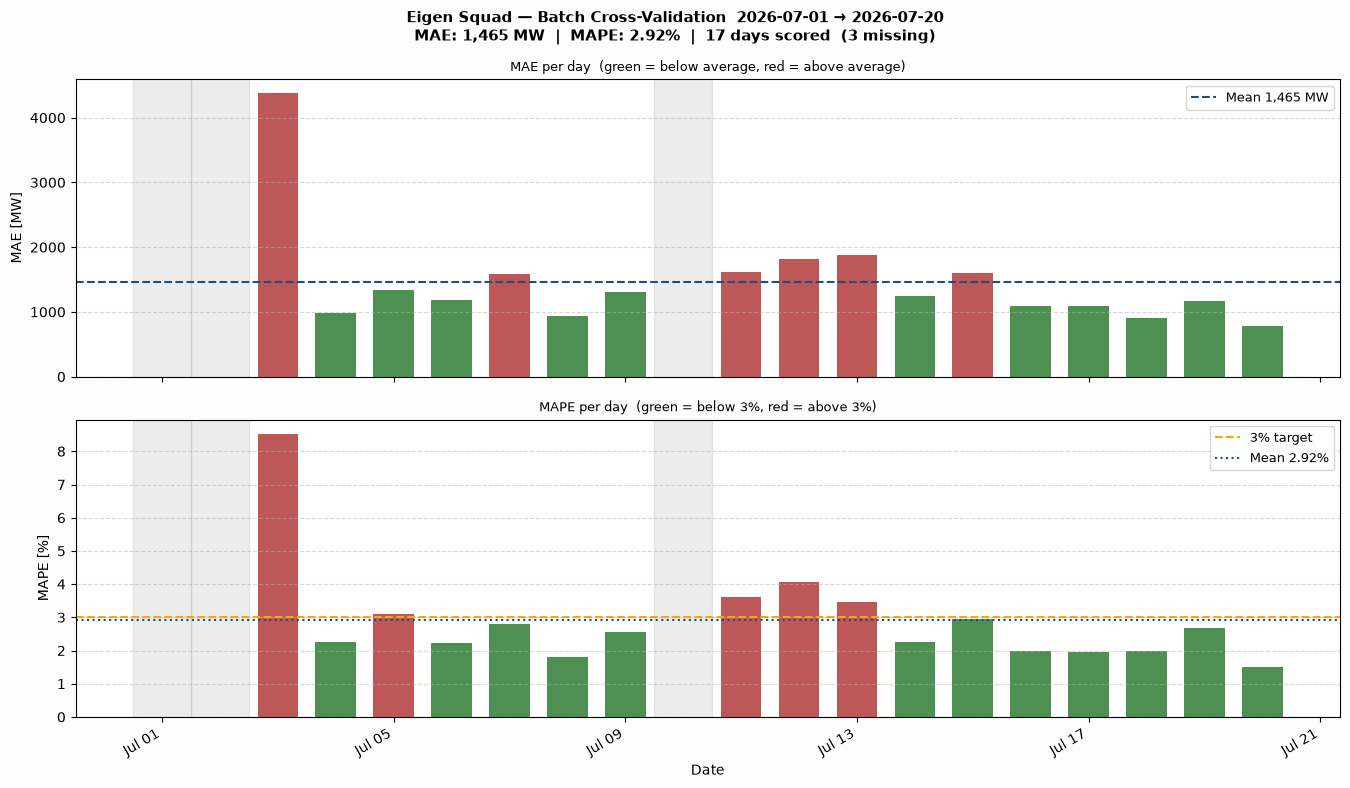

In [7]:
# ── Cell 7: Overview chart — MAE & MAPE per day ────────────────────────────────

dates       = df_cv.index
colors_mae  = ['#2E7D32' if v < overall_mae else '#B33A3A' for v in df_cv['mae_mw']]
colors_mape = ['#2E7D32' if v < 3.0         else '#B33A3A' for v in df_cv['mape_pct']]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(10, len(df_cv) * 0.8), 8),
                                sharex=True, facecolor='#fdfdfd')
fig.suptitle(
    f'Eigen Squad — Batch Cross-Validation  {START_DATE} → {END_DATE}\n'
    f'MAE: {overall_mae:,.0f} MW  |  MAPE: {overall_mape:.2f}%  |  '
    f'{len(df_cv)} days scored  ({len(missing_dates)} missing)',
    fontsize=11, fontweight='bold',
)

ax1.bar(dates, df_cv['mae_mw'], color=colors_mae, alpha=0.85, width=0.7)
ax1.axhline(overall_mae, color='#1F4E79', linewidth=1.5, linestyle='--',
            label=f'Mean {overall_mae:,.0f} MW')
ax1.set_ylabel('MAE [MW]')
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_title('MAE per day  (green = below average, red = above average)', fontsize=9)

ax2.bar(dates, df_cv['mape_pct'], color=colors_mape, alpha=0.85, width=0.7)
ax2.axhline(3.0, color='orange', linewidth=1.5, linestyle='--', label='3% target')
ax2.axhline(overall_mape, color='#1F4E79', linewidth=1.5, linestyle=':',
            label=f'Mean {overall_mape:.2f}%')
ax2.set_ylabel('MAPE [%]')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.set_title('MAPE per day  (green = below 3%, red = above 3%)', fontsize=9)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.autofmt_xdate(rotation=30)

# Mark missing dates as grey shading if any
for md in missing_dates:
    ts = pd.Timestamp(md, tz='UTC')
    for ax in (ax1, ax2):
        ax.axvspan(ts - pd.Timedelta(hours=12), ts + pd.Timedelta(hours=12),
                   color='grey', alpha=0.15, label='_no_legend_')

plt.tight_layout()
plt.show()

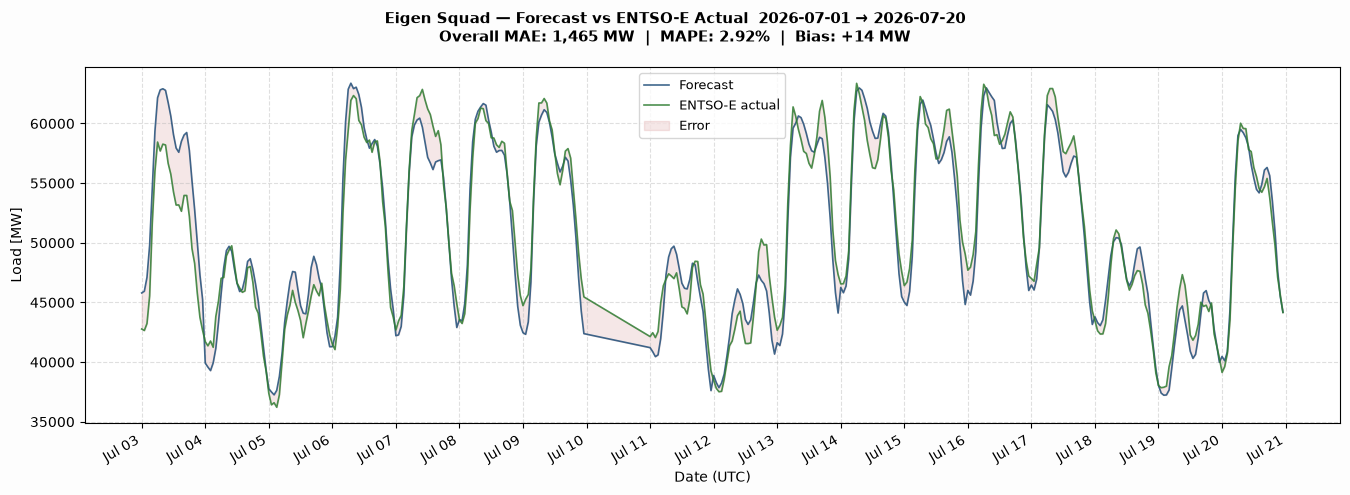

In [8]:
# ── Cell 8: Forecast vs Actual trend across the full window ────────────────────

fig, ax = plt.subplots(figsize=(max(12, len(df_cv) * 0.8), 5), facecolor='#fdfdfd')
fig.suptitle(
    f'Eigen Squad — Forecast vs ENTSO-E Actual  {START_DATE} → {END_DATE}\n'
    f'Overall MAE: {overall_mae:,.0f} MW  |  MAPE: {overall_mape:.2f}%  |  Bias: {overall_bias:+,.0f} MW',
    fontsize=11, fontweight='bold',
)

ax.plot(combined.index, combined['forecast_mw'],
        color='#1F4E79', linewidth=1.2, label='Forecast', alpha=0.85)
ax.plot(combined.index, combined['actual_mw'],
        color='#2E7D32', linewidth=1.2, label='ENTSO-E actual', alpha=0.85)
ax.fill_between(combined.index, combined['forecast_mw'], combined['actual_mw'],
                alpha=0.12, color='#B33A3A', label='Error')

ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Load [MW]')
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()

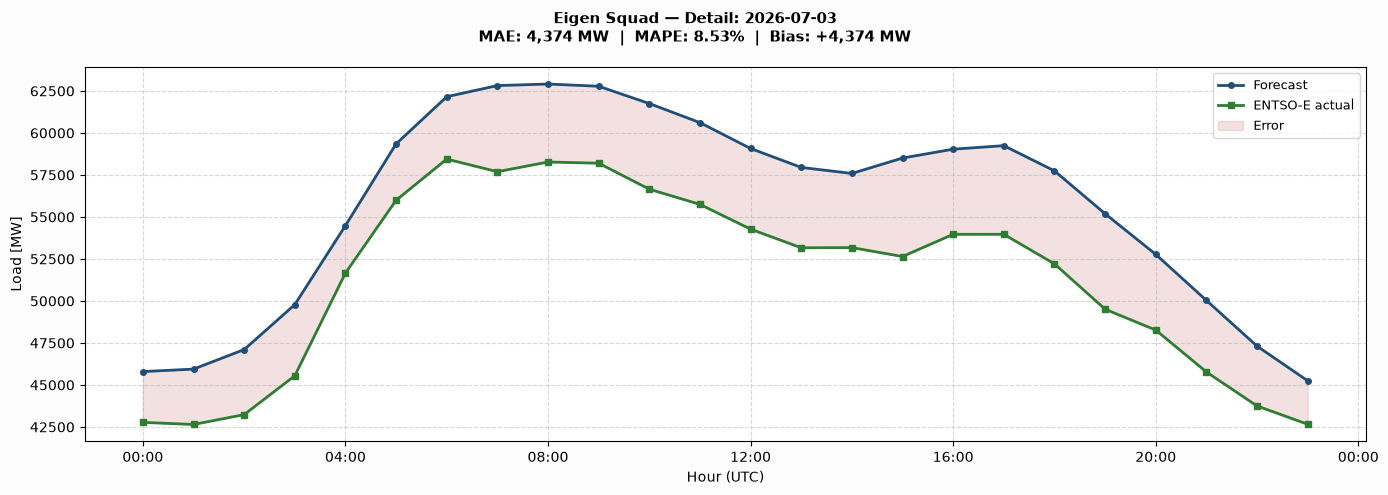

Showing: 2026-07-03  (set DETAIL_DATE above to view a different day)


In [9]:
# ── Cell 9: Detail plot — single day ──────────────────────────────────────────
#
# Set DETAIL_DATE to any scored date, or None to use the worst-MAE day.
# ─────────────────────────────────────────────────────────────────────────────
DETAIL_DATE = None   # e.g. '2026-07-06'  or None → worst-MAE day
# ─────────────────────────────────────────────────────────────────────────────

if DETAIL_DATE is None:
    focus = worst_day
else:
    focus = pd.Timestamp(DETAIL_DATE, tz='UTC')
    if focus not in df_cv.index:
        available = ', '.join(d.strftime('%Y-%m-%d') for d in df_cv.index)
        raise ValueError(f'{DETAIL_DATE} not in scored days. Available: {available}')

focus_str = focus.strftime('%Y-%m-%d')
day_mask  = combined.index.normalize() == focus
day_data  = combined[day_mask]

day_mae  = df_cv.loc[focus, 'mae_mw']
day_mape = df_cv.loc[focus, 'mape_pct']
day_bias = df_cv.loc[focus, 'bias_mw']

fig, ax = plt.subplots(figsize=(14, 5), facecolor='#fdfdfd')
fig.suptitle(
    f'Eigen Squad — Detail: {focus_str}\n'
    f'MAE: {day_mae:,.0f} MW  |  MAPE: {day_mape:.2f}%  |  Bias: {day_bias:+,.0f} MW',
    fontsize=11, fontweight='bold',
)

ax.plot(day_data.index, day_data['forecast_mw'],
        color='#1F4E79', linewidth=2, marker='o', markersize=4, label='Forecast')
ax.plot(day_data.index, day_data['actual_mw'],
        color='#2E7D32', linewidth=2, marker='s', markersize=4, label='ENTSO-E actual')
ax.fill_between(day_data.index, day_data['forecast_mw'], day_data['actual_mw'],
                alpha=0.15, color='#B33A3A', label='Error')

ax.set_xlabel('Hour (UTC)')
ax.set_ylabel('Load [MW]')
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.5)
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 4, 8, 12, 16, 20]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()
print(f'Showing: {focus_str}  (set DETAIL_DATE above to view a different day)')

In [10]:
# ── Cell 10 (optional): Save results ──────────────────────────────────────────
#
# Set SAVE_RESULTS = True to write a CSV summary to data/cross_validation/
# ─────────────────────────────────────────────────────────────────────────────
SAVE_RESULTS = False
# ─────────────────────────────────────────────────────────────────────────────

if SAVE_RESULTS:
    out_dir = REPO_ROOT / 'data' / 'cross_validation'
    out_dir.mkdir(parents=True, exist_ok=True)

    stem     = f'{START_DATE}_to_{END_DATE}'
    csv_path = out_dir / f'cv_eigen_squad_{stem}.csv'
    df_cv.to_csv(csv_path)
    print(f'Saved : {csv_path}')
else:
    print('SAVE_RESULTS = False  →  nothing written to disk.')

SAVE_RESULTS = False  →  nothing written to disk.
